In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("2 loan_approval_data.csv")
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [3]:
df.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


In [4]:
df.info

<bound method DataFrame.info of      Applicant_ID  Applicant_Income  Coapplicant_Income Employment_Status  \
0             1.0           17795.0              1387.0          Salaried   
1             2.0            2860.0              2679.0          Salaried   
2             3.0            7390.0              2106.0          Salaried   
3             4.0           13964.0              8173.0          Salaried   
4             5.0           13284.0              4223.0     Self-employed   
..            ...               ...                 ...               ...   
995         996.0               NaN              9092.0          Salaried   
996         997.0            3279.0              6356.0     Self-employed   
997         998.0           15192.0              8433.0          Contract   
998         999.0            9083.0              7380.0        Unemployed   
999        1000.0           13093.0              2385.0          Salaried   

      Age Marital_Status  Dependents  Credi

In [5]:
df.dtypes

Applicant_ID          float64
Applicant_Income      float64
Coapplicant_Income    float64
Employment_Status      object
Age                   float64
Marital_Status         object
Dependents            float64
Credit_Score          float64
Existing_Loans        float64
DTI_Ratio             float64
Savings               float64
Collateral_Value      float64
Loan_Amount           float64
Loan_Term             float64
Loan_Purpose           object
Property_Area          object
Education_Level        object
Gender                 object
Employer_Category      object
Loan_Approved          object
dtype: object

# Handling Missing values

In [6]:
cat_col = df.select_dtypes(include=['object']).columns
num_col = df.select_dtypes(include=['number']).columns

In [7]:
from sklearn.impute import SimpleImputer

In [8]:
num_imp = SimpleImputer(strategy='mean')
df[num_col] = num_imp.fit_transform(df[num_col])

In [9]:
cat_imp = SimpleImputer(strategy='most_frequent') #{'most_frequent', 'constant', 'median', 'mean'}
df[cat_col] = cat_imp.fit_transform(df[cat_col])

In [10]:
df.isnull().sum().sum()

np.int64(0)

### Exporting clean data

In [11]:
#df.to_csv('Cleaned_insurance_data.csv', index=False)

# EDA

In [12]:
#df_1 = pd.read_csv("Cleaned_insurance_data.csv")

In [13]:
#import sweetviz as sv

In [14]:
#report = sv.analyze(df_1)
#report.show_html('loan_eda_report_1.html')

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='Credit_Score', ylabel='Count'>

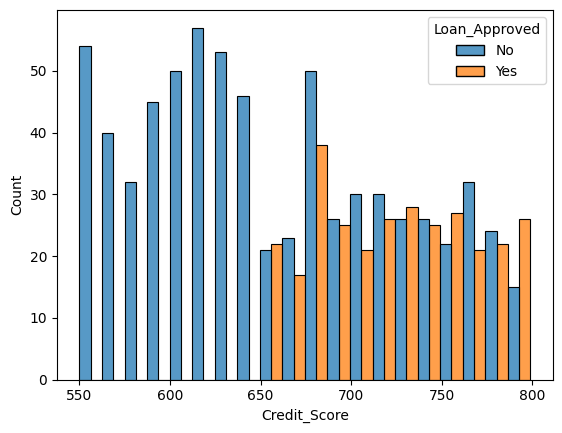

In [17]:
sns.histplot(
    data = df,
    x= 'Credit_Score',
    hue= 'Loan_Approved',
    bins= 20,
    multiple='dodge'
)

In [18]:
df = df.drop("Applicant_ID", axis=1)

# Encoding

In [19]:
X = df.drop(columns=["Loan_Approved"])
Y = df["Loan_Approved"]

In [21]:
Y.head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: Loan_Approved, dtype: object

### One Hot Encoding

In [23]:
X = pd.get_dummies(X, columns=["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"], dtype= float)
X.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,Gender_Female,Gender_Male,Employer_Category_Business,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


### Label Encoding

In [24]:
from sklearn.preprocessing import LabelEncoder

In [30]:
le = LabelEncoder()
#le.fit_transform(["", ""])

In [ ]:
'''
from sklearn.preprocessing import LabelEncoder

# Define the columns to be transformed
columns_to_transform = ['column1', 'column2', 'column3']  # replace with your column names

# Apply LabelEncoder to each column
for column in columns_to_transform:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
'''

In [25]:
# Define the columns to be transformed
columns_to_transform = ['Education_Level']  # replace with your column names

# Apply LabelEncoder to each column
X[columns_to_transform] = X[columns_to_transform].apply(LabelEncoder().fit_transform)

In [31]:
# Apply LabelEncoder to each column
Y = le.fit_transform(Y)

#### joining data again for analyzing purpose

In [38]:
df_1 = pd.concat([X, pd.DataFrame(Y)], axis=1)

In [39]:
df_1.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Property_Area_Semiurban,Property_Area_Urban,Gender_Female,Gender_Male,Employer_Category_Business,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,0
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1


In [40]:
import sweetviz as sv
report = sv.analyze(df_1)
report.show_html('loan_eda_report_2.html')

                                             |          | [  0%]   00:00 -> (? left)

Report loan_eda_report_2.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


# Train Test Split

In [43]:
from sklearn.model_selection import train_test_split

In [44]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Scaling and Creating Pipeline

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB

In [42]:
# Pipeline for Logistic Regression
log_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(max_iter=1000))
])

# Pipeline for Naive Bayes
nb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('nb', BernoulliNB())
])

# Data Training

In [45]:
log_reg_pipeline.fit(x_train, y_train)
y_pred_log_reg = log_reg_pipeline.predict(x_test)

In [46]:
nb_pipeline.fit(x_train, y_train)
y_pred_nb = nb_pipeline.predict(x_test)

In [ ]:
# Now you can use the pipelines to fit and predict on your data
# For example:
# log_reg_pipeline.fit(X_train, y_train)
# y_pred_log_reg = log_reg_pipeline.predict(X_test)

# nb_pipeline.fit(X_train, y_train)
# y_pred_nb = nb_pipeline.predict(X_test)

# Data Evaluation

In [47]:
from sklearn.metrics import precision_score, accuracy_score, recall_score, f1_score, confusion_matrix

In [51]:
from sklearn.metrics import roc_auc_score

In [ ]:
from sklearn.

#### Log Regeression Evaluation

In [48]:
print("Log Regeression Evaluation: ") 
print("precision_score:", precision_score(y_test, y_pred_log_reg))
print("accuracy_score:", accuracy_score(y_test, y_pred_log_reg))
print("recall_score:", recall_score(y_test, y_pred_log_reg))
print("f1_score:", f1_score(y_test, y_pred_log_reg))
confusion_matrix(y_test, y_pred_log_reg)


Log Regeression Evaluation: 
precision_score: 0.7833333333333333
accuracy_score: 0.865
recall_score: 0.7704918032786885
f1_score: 0.7768595041322314


array([[126,  13],
       [ 14,  47]])

#### Naive Byes Evaluation

In [49]:
print("Naive Byes Evaluation: ") 
print("precision_score:", precision_score(y_test, y_pred_nb))
print("accuracy_score:", accuracy_score(y_test, y_pred_nb))
print("recall_score:", recall_score(y_test, y_pred_nb))
print("f1_score:", f1_score(y_test, y_pred_nb))
confusion_matrix(y_test, y_pred_nb)

Naive Byes Evaluation: 
precision_score: 0.7115384615384616
accuracy_score: 0.805
recall_score: 0.6065573770491803
f1_score: 0.6548672566371682


array([[124,  15],
       [ 24,  37]])

- use precision for false positives.
- use recall for false negatives.

In [53]:
import numpy as np

In [58]:
print("confusion_matrix", confusion_matrix(y_test, y_pred_log_reg))
print("Data proportion:", pd.DataFrame(y_pred_log_reg).value_counts(normalize=True))
print("roc_auc_score", roc_auc_score(y_test, y_pred_log_reg))

confusion_matrix [[126  13]
 [ 14  47]]
Data proportion: 0
0    0.7
1    0.3
Name: proportion, dtype: float64
roc_auc_score 0.8384833117112866


In [ ]:
cross_val_score(model, X, y, cv=5, scoring='f1')